# DPNN 1D - FDTD vs PSTD Joint Parameter Estimation
This notebook dynamically compares the FDTD and PSTD solvers during joint estimation of $p_0(x)$, $\gamma$, and $\nu$.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Dynamic Physical Solvers

In [2]:
# --- FDTD SOLVER ---
def interior_assembly(Nx, dx, dt, c, gamma, nu, device='cpu'):
    I = torch.eye(Nx, device=device)
    D = torch.zeros((Nx, Nx), device=device)
    idx = torch.arange(0, Nx)
    D[idx, idx] = -2.0
    idx_off = torch.arange(0, Nx-1)
    D[idx_off+1, idx_off] = 1.0
    D[idx_off, idx_off+1] = 1.0
    D = D / (dx**2)
    A = (1 + gamma*dt/2)*I - (nu*dt/2)*D
    B = 2*I + (c**2 * dt**2)*D
    C = -(1 - gamma*dt/2)*I - (nu*dt/2)*D
    return A, B, C

def apply_bc(A, B, C, bcType, Nx, dx, dt, c, gamma, nu, q, r, device='cpu'):
    A_mod, B_mod, C_mod = A.clone(), B.clone(), C.clone()
    if bcType.lower() == 'neumannghost':
        A_mod[0, 1] *= 2; B_mod[0, 1] *= 2; C_mod[0, 1] *= 2
        A_mod[-1, -2] *= 2; B_mod[-1, -2] *= 2; C_mod[-1, -2] *= 2
        def rhsFun(t): return torch.zeros(Nx, 1, device=device)
    else: raise ValueError(f"Unknown BC type: {bcType}")
    return A_mod, B_mod, C_mod, rhsFun

class DifferentiableFDTD1D(nn.Module):
    def __init__(self, Nx, dx, dt, L, T, bcType, q, r, device='cpu'):
        super().__init__()
        self.Nx = Nx; self.dx = dx; self.dt = dt; self.L = L; self.T = T
        self.bcType = bcType; self.q = q; self.r = r; self.device = device
        self.x_grid = torch.linspace(0, L, Nx, device=device)
        self.t_grid = torch.arange(0, T+dt/2, dt, device=device)
        self.Nt = len(self.t_grid)
        
    def forward(self, u0, v0, f_fun, gamma, nu):
        c = 1.0 # Fixed wave speed
        A, B, C = interior_assembly(self.Nx, self.dx, self.dt, c, gamma, nu, self.device)
        A_mod, B_mod, C_mod, rhsFun = apply_bc(A, B, C, self.bcType, self.Nx, self.dx, self.dt, c, gamma, nu, self.q, self.r, self.device)
        A_inv = torch.linalg.inv(A_mod)
        
        u_array = [u0]
        uxx0 = torch.zeros(self.Nx, device=self.device)
        uxx0[1:-1] = (u0[2:] - 2*u0[1:-1] + u0[:-2]) / (self.dx**2)
        uxx0[0] = uxx0[1]; uxx0[-1] = uxx0[-2]
        vxx0 = torch.zeros(self.Nx, device=self.device)
        vxx0[1:-1] = (v0[2:] - 2*v0[1:-1] + v0[:-2]) / (self.dx**2)
        vxx0[0] = vxx0[1]; vxx0[-1] = vxx0[-2]
        utt0 = (c**2)*uxx0 + nu*vxx0 - gamma*v0 + f_fun(self.x_grid, 0)
        
        uPrev = u0
        uCurr = u0 + self.dt*v0 + 0.5*(self.dt**2)*utt0
        u_array.append(uCurr)
        for n in range(1, self.Nt - 1):
            t = self.t_grid[n]
            rhs = torch.mv(B_mod, uCurr) + torch.mv(C_mod, uPrev) + (self.dt**2)*f_fun(self.x_grid, t)
            rhs = rhs + rhsFun(t).squeeze()
            uNext = torch.mv(A_inv, rhs)
            u_array.append(uNext)
            uPrev = uCurr
            uCurr = uNext
        return torch.stack(u_array, dim=1)

# --- PSTD SOLVER ---
def dct_fft(x):
    N = x.shape[-1]
    x_ext = torch.cat([x, x.flip(-1)], dim=-1)
    X = torch.fft.fft(x_ext, dim=-1)
    X = X[..., :N]
    k = torch.arange(N, device=x.device).float()
    phase = torch.exp(-1j * torch.pi * k / (2 * N))
    X_real = (X * phase).real
    X_real = X_real / torch.sqrt(torch.tensor(2.0 * N, device=x.device))
    X_real[..., 0] /= torch.sqrt(torch.tensor(2.0, device=x.device))
    return X_real

def idct_fft(X):
    N = X.shape[-1]
    X_unnorm = X * torch.sqrt(torch.tensor(2.0 * N, device=X.device))
    X_unnorm[..., 0] *= torch.sqrt(torch.tensor(2.0, device=X.device))
    k = torch.arange(N, device=X.device).float()
    phase = torch.exp(1j * torch.pi * k / (2 * N))
    Y = X_unnorm * phase
    Y_ext = torch.zeros(*X.shape[:-1], 2*N, dtype=torch.complex64, device=X.device)
    Y_ext[..., :N] = Y
    Y_ext[..., N] = 0.0
    Y_ext[..., N+1:] = torch.conj(Y[..., 1:].flip(-1))
    x_ext = torch.fft.ifft(Y_ext, dim=-1)
    x_real = x_ext.real[..., :N]
    return x_real

class DifferentiablePSTD1D(nn.Module):
    def __init__(self, Nx, dx, dt, L, T, device='cpu'):
        super().__init__()
        self.Nx = Nx; self.dx = dx; self.dt = dt; self.L = L; self.T = T; self.device = device
        self.x_grid = (torch.arange(Nx, device=device) + 0.5) * dx 
        self.t_grid = torch.arange(0, T+dt/2, dt, device=device)
        self.Nt = len(self.t_grid)
        
        m = torch.arange(Nx, device=device).float()
        self.lambda_val = -((m * torch.pi / L)**2)
        
    def forward(self, u0, v0, f_fun, gamma, nu):
        c = 1.0 # Fixed wave speed
        d_val = gamma - nu * self.lambda_val
        
        discr = d_val**2 + 4 * c**2 * self.lambda_val
        
        mask_lam0_dj0 = (self.lambda_val == 0) & (d_val == 0)
        mask_lam0_djN0 = (self.lambda_val == 0) & (d_val != 0)
        mask_lamN0_d0 = (self.lambda_val != 0) & (torch.abs(discr) < 1e-12)
        mask_lamN0_dneg = (self.lambda_val != 0) & (discr <= -1e-12)
        mask_lamN0_dpos = (self.lambda_val != 0) & (discr >= 1e-12)
        
        t = self.t_grid.unsqueeze(1) # (Nt, 1)
        d_val_2d = d_val.unsqueeze(0) # (1, Nx)
        discr_2d = discr.unsqueeze(0) # (1, Nx)
        e = torch.exp(-d_val_2d * t / 2) # (Nt, Nx)
        
        S11 = torch.zeros((self.Nt, self.Nx), device=self.device)
        S12 = torch.zeros((self.Nt, self.Nx), device=self.device)
        
        if mask_lam0_dj0.any():
            S11[:, mask_lam0_dj0] = 1.0
            S12[:, mask_lam0_dj0] = t
            
        if mask_lam0_djN0.any():
            dj = d_val_2d[:, mask_lam0_djN0]
            S11[:, mask_lam0_djN0] = 1.0
            S12[:, mask_lam0_djN0] = (1 - torch.exp(-dj*t))/dj
            
        if mask_lamN0_d0.any():
            dj = d_val_2d[:, mask_lamN0_d0]; ee = e[:, mask_lamN0_d0]
            S11[:, mask_lamN0_d0] = ee * (1 + dj*t/2)
            S12[:, mask_lamN0_d0] = ee * t
            
        if mask_lamN0_dneg.any():
            dj = d_val_2d[:, mask_lamN0_dneg]; ee = e[:, mask_lamN0_dneg]
            omega = torch.sqrt(-discr_2d[:, mask_lamN0_dneg])/2
            co = torch.cos(omega*t); si = torch.sin(omega*t)
            S11[:, mask_lamN0_dneg] = ee * (co + si * dj/(2*omega))
            S12[:, mask_lamN0_dneg] = ee * (si / omega)
            
        if mask_lamN0_dpos.any():
            dj = d_val_2d[:, mask_lamN0_dpos]
            delta = torch.sqrt(discr_2d[:, mask_lamN0_dpos])
            exp_plus = torch.exp((-dj + delta)*t/2)
            exp_minus = torch.exp((-dj - delta)*t/2)
            S11[:, mask_lamN0_dpos] = 0.5 * exp_plus * (1 + dj/delta) + 0.5 * exp_minus * (1 - dj/delta)
            S12[:, mask_lamN0_dpos] = (exp_plus - exp_minus) / delta

        Um0 = dct_fft(u0).unsqueeze(0) # (1, Nx)
        Vm0 = dct_fft(v0).unsqueeze(0) # (1, Nx)
        
        Um_all = S11 * Um0 + S12 * Vm0 # (Nt, Nx)
        u_all = idct_fft(Um_all) # (Nt, Nx)
        return u_all.T # (Nx, Nt)

## 2. SIREN Architecture & Inverse Wrapper

In [3]:
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0; self.is_first = is_first; self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.init_weights()
    def init_weights(self):
        with torch.no_grad():
            if self.is_first: self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)      
            else: self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0, np.sqrt(6 / self.in_features) / self.omega_0)
    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))

class SIREN(nn.Module):
    def __init__(self, in_features=1, hidden_features=32, hidden_layers=1, out_features=1, outermost_linear=True):
        super().__init__()
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, is_first=True))
        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, is_first=False))
        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)
            with torch.no_grad():
                final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / 30, np.sqrt(6 / hidden_features) / 30)
            self.net.append(final_linear)
        else: self.net.append(SineLayer(hidden_features, out_features, is_first=False))
        self.net = nn.Sequential(*self.net)
    def forward(self, coords):
        return self.net(coords).squeeze()

class InverseDPNN(nn.Module):
    def __init__(self, init_gamma, init_nu):
        super().__init__()
        self.siren = SIREN()
        self.raw_gamma = nn.Parameter(torch.tensor(float(init_gamma), dtype=torch.float32))
        self.raw_nu = nn.Parameter(torch.tensor(float(init_nu), dtype=torch.float32))
        
    def forward(self, coords):
        p0 = self.siren(coords)
        gamma = torch.abs(self.raw_gamma)
        nu = torch.abs(self.raw_nu)
        return p0, gamma, nu

## 3. Comparison Loop over Multiple Experiments

Experiment: 0_StandingWaves (Multi-modal)
Training FDTD-DPNN...
FDTD Time: 24.13s
Training PSTD-DPNN...
PSTD Time: 11.99s
Final FDTD: gamma=0.0093, nu=0.0059 | NMSE=6.4534e-03
Final PSTD: gamma=0.0446, nu=0.0034 | NMSE=7.3752e-03


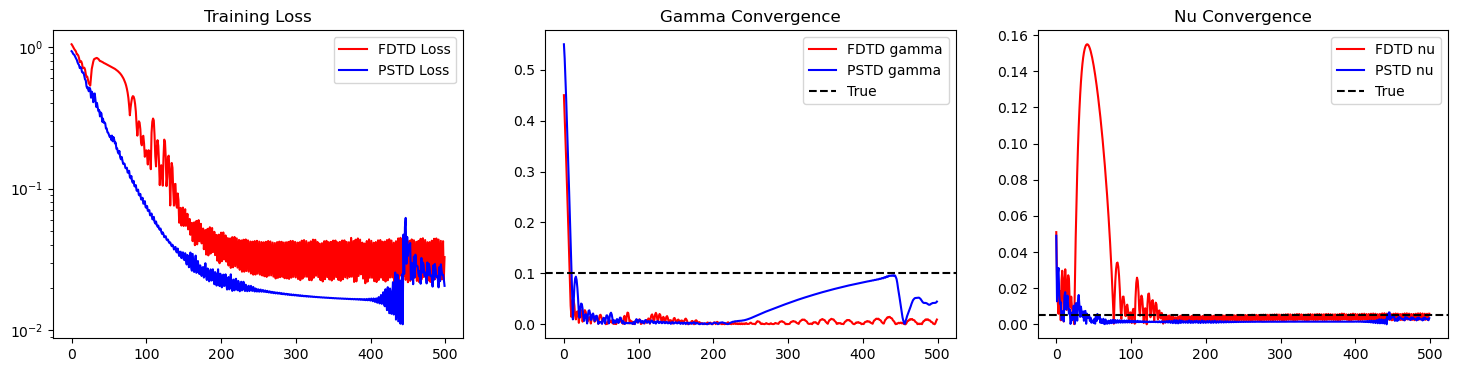

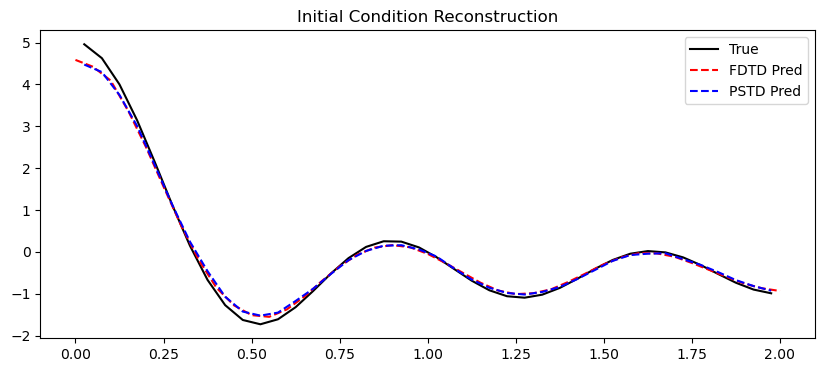

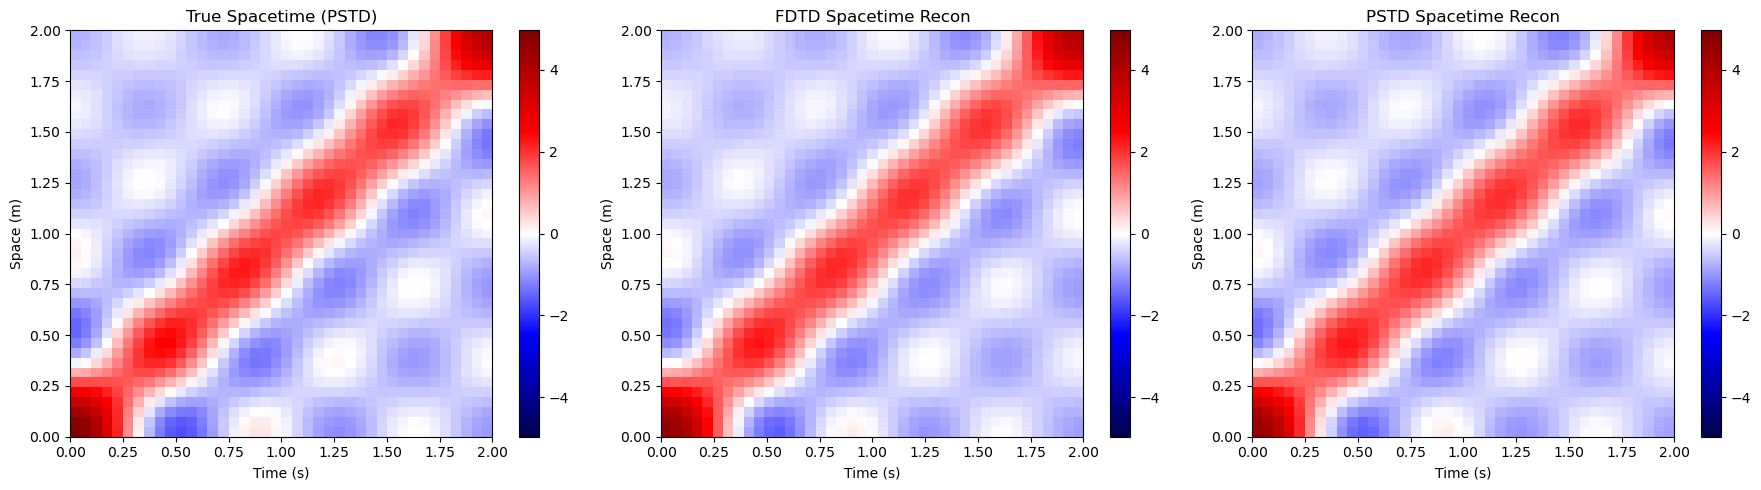




Experiment: 1_Smooth (Smooth)
Training FDTD-DPNN...
FDTD Time: 27.73s
Training PSTD-DPNN...
PSTD Time: 11.43s
Final FDTD: gamma=0.2285, nu=0.0011 | NMSE=7.2331e-02
Final PSTD: gamma=0.1896, nu=0.0017 | NMSE=8.3090e-02


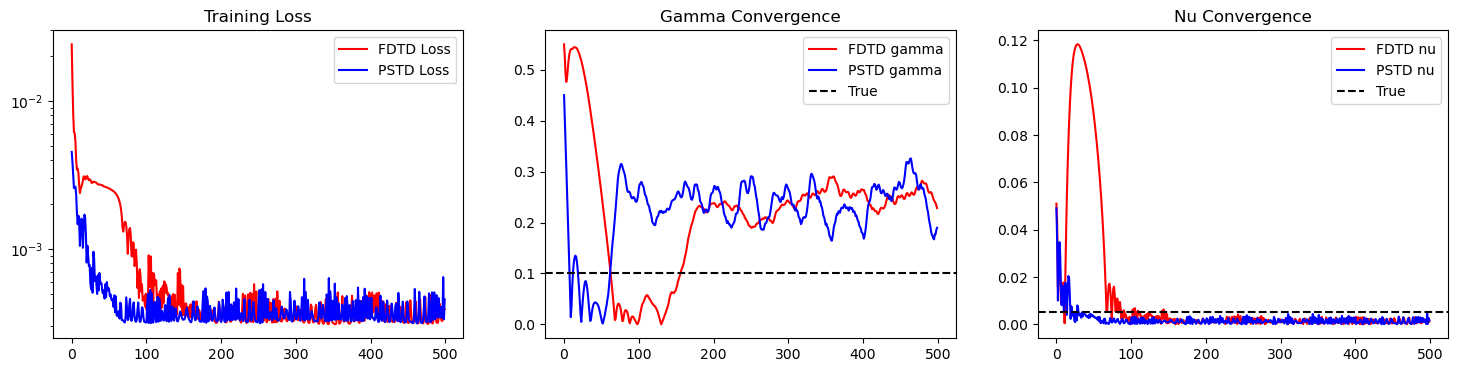

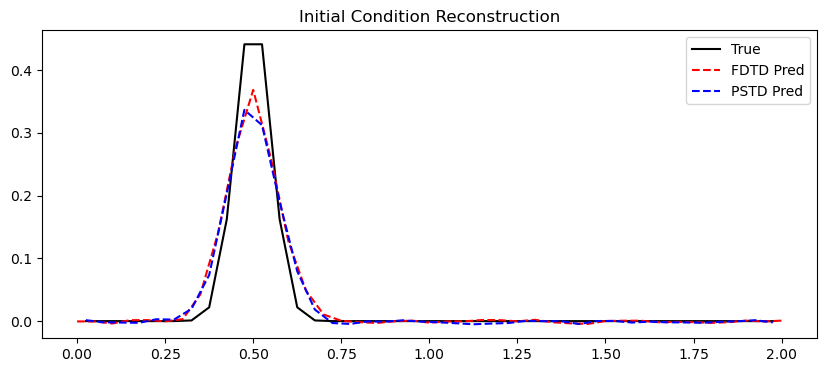

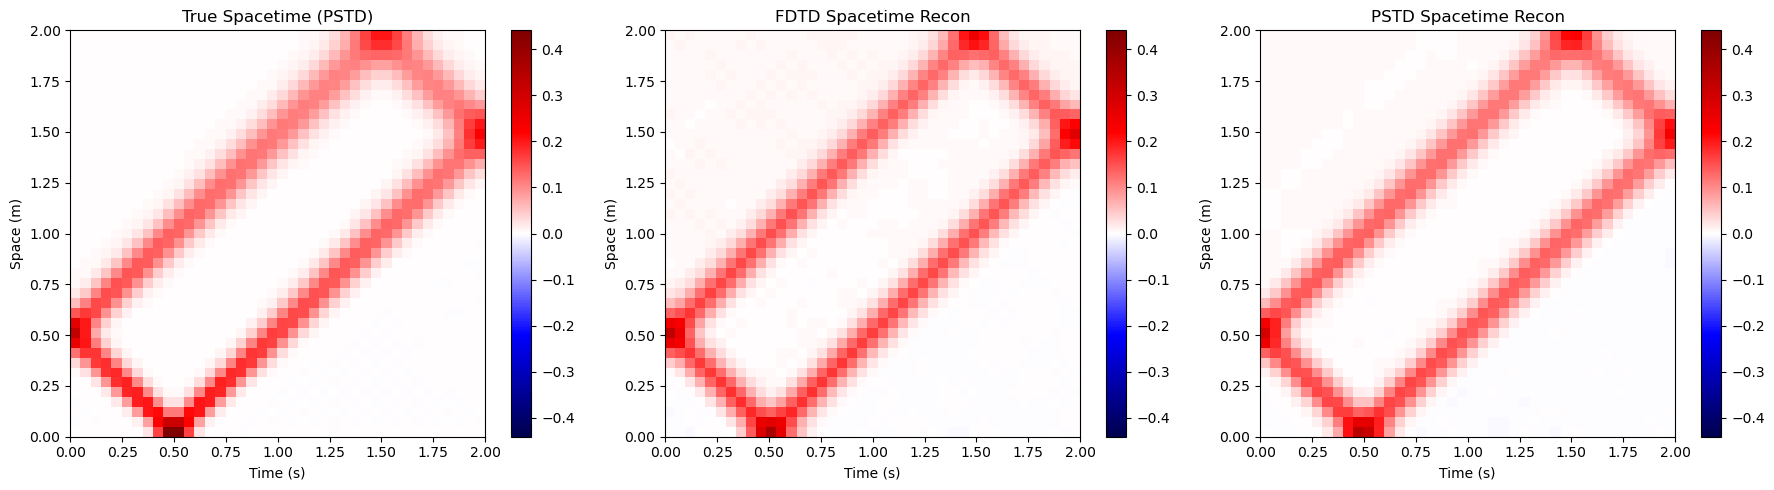




Experiment: 2_Triangle (Non-smooth)
Training FDTD-DPNN...
FDTD Time: 28.11s
Training PSTD-DPNN...
PSTD Time: 11.89s
Final FDTD: gamma=0.0185, nu=0.0164 | NMSE=6.4902e-01
Final PSTD: gamma=0.0020, nu=0.0029 | NMSE=3.5217e-01


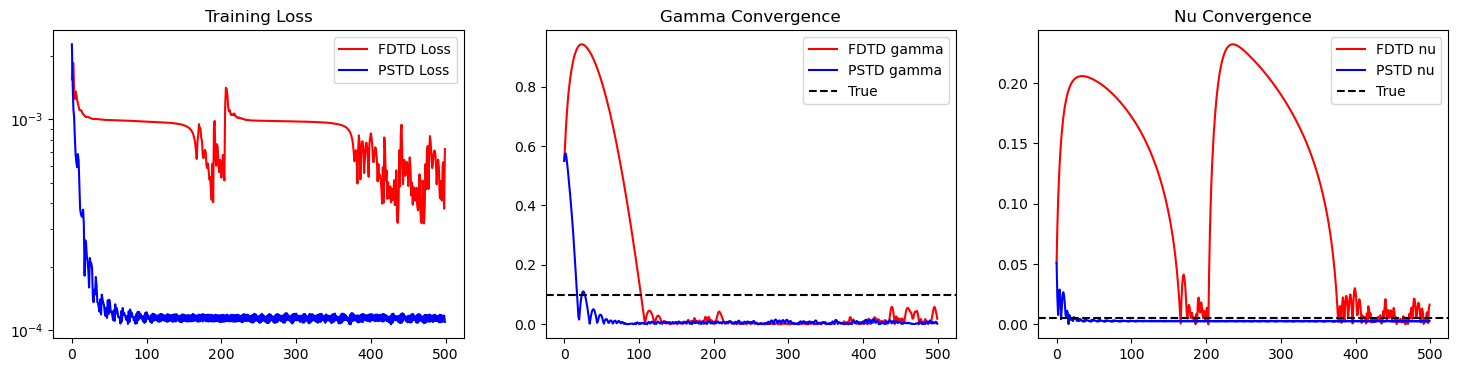

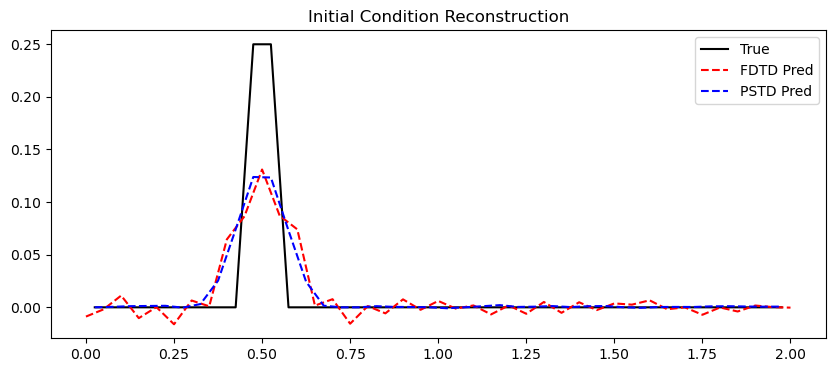

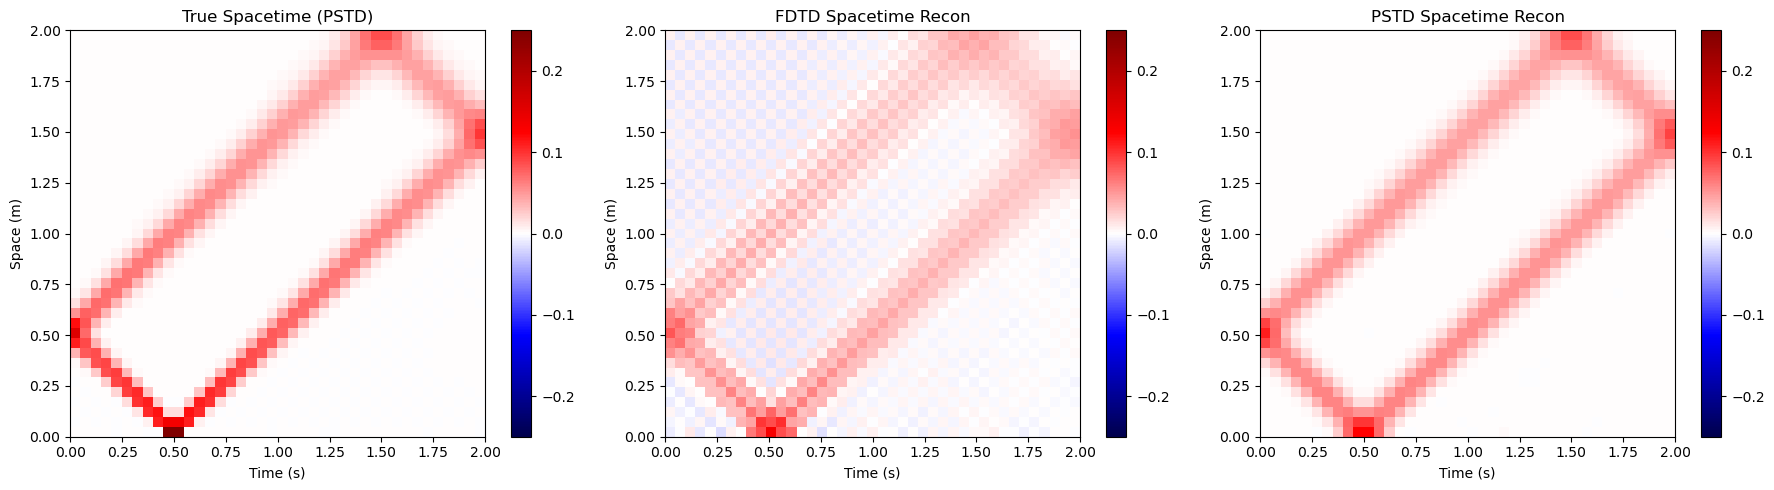

In [4]:
experiments = [
    {'name': '0_StandingWaves', 'true_gamma': 0.1, 'true_nu': 0.005, 'u0_type': 'standingWaves', 'desc': 'Multi-modal', 'lambda_sp': 0.005, 'lambda_smooth': 0.1},
    {'name': '1_Smooth', 'true_gamma': 0.1, 'true_nu': 0.005, 'u0_type': 'smoothPulse', 'desc': 'Smooth', 'lambda_sp': 0.005, 'lambda_smooth': 0.1},
    {'name': '2_Triangle', 'true_gamma': 0.1, 'true_nu': 0.005, 'u0_type': 'trianglePulse', 'desc': 'Non-smooth', 'lambda_sp': 0.005, 'lambda_smooth': 0.1}
]

for exp in experiments:
    print("="*80)
    print(f"Experiment: {exp['name']} ({exp['desc']})")
    print("="*80)
    
    L = 2.0; T = 2.0; dx = 0.05; dt = 0.05; bcType = 'neumannGhost'; q = 0.0; r = 0.0
    true_gamma = exp['true_gamma']; true_nu = exp['true_nu']
    
    Nx_fdtd = int(L/dx) + 1
    Nx_pstd = int(L/dx)
    fdtd_model = DifferentiableFDTD1D(Nx_fdtd, dx, dt, L, T, bcType, q, r, device=device)
    pstd_model = DifferentiablePSTD1D(Nx_pstd, dx, dt, L, T, device=device)
    
    x_grid_fdtd = fdtd_model.x_grid
    x_grid_pstd = pstd_model.x_grid
    
    def get_u0(x_grid):
        u0 = torch.zeros_like(x_grid)
        mu = L / 4; sigma = L / 40; M = 5
        if exp['u0_type'] == 'smoothPulse':
            for m in range(-M, M+1):
                u0 += 0.5 * torch.exp(-0.5 * ((x_grid - (2*m*L + mu)) / sigma)**2)
                u0 += 0.5 * torch.exp(-0.5 * ((x_grid - (2*m*L - mu)) / sigma)**2)
        elif exp['u0_type'] == 'trianglePulse':
            for m in range(-M, M+1):
                u0 += 0.5 * torch.clamp(1 - torch.abs(x_grid - (2*m*L + mu))/sigma, min=0)
                u0 += 0.5 * torch.clamp(1 - torch.abs(x_grid - (2*m*L - mu))/sigma, min=0)
        elif exp['u0_type'] == 'standingWaves':
            for m in range(1, 6):
                u0 += torch.cos(m * torch.pi * x_grid / L)
        return u0
        
    u0_true_fdtd = get_u0(x_grid_fdtd); u0_true_pstd = get_u0(x_grid_pstd)
    def f_fun(x, t): return torch.zeros_like(x)
    
    with torch.no_grad():
        p_true_field_fdtd = fdtd_model(u0_true_fdtd, torch.zeros_like(x_grid_fdtd), f_fun, torch.tensor(true_gamma), torch.tensor(true_nu))
        p_true_field_pstd = pstd_model(u0_true_pstd, torch.zeros_like(x_grid_pstd), f_fun, torch.tensor(true_gamma), torch.tensor(true_nu))
        
    num_sensors = 10
    snr_db = 30
    
    sensor_indices_fdtd = torch.randperm(Nx_fdtd - 2)[:num_sensors] + 1
    sensor_indices_fdtd, _ = torch.sort(sensor_indices_fdtd)
    p_obs_fdtd = p_true_field_fdtd[sensor_indices_fdtd, :]
    noise_fdtd = torch.sqrt(torch.mean(p_obs_fdtd**2) / (10**(snr_db/10))) * torch.randn_like(p_obs_fdtd)
    p_obs_noisy_fdtd = p_obs_fdtd + noise_fdtd
    
    sensor_indices_pstd = torch.randperm(Nx_pstd - 2)[:num_sensors] + 1
    sensor_indices_pstd, _ = torch.sort(sensor_indices_pstd)
    p_obs_pstd = p_true_field_pstd[sensor_indices_pstd, :]
    noise_pstd = torch.sqrt(torch.mean(p_obs_pstd**2) / (10**(snr_db/10))) * torch.randn_like(p_obs_pstd)
    p_obs_noisy_pstd = p_obs_pstd + noise_pstd
    
    init_gamma = 0.5; init_nu = 0.001
    model_fdtd = InverseDPNN(init_gamma, init_nu).to(device)
    model_pstd = InverseDPNN(init_gamma, init_nu).to(device)
    
    opt_fdtd_siren = torch.optim.Adam(model_fdtd.siren.parameters(), lr=1e-3)
    opt_fdtd_phys = torch.optim.Adam([model_fdtd.raw_gamma, model_fdtd.raw_nu], lr=5e-2)
    opt_pstd_siren = torch.optim.Adam(model_pstd.siren.parameters(), lr=1e-3)
    opt_pstd_phys = torch.optim.Adam([model_pstd.raw_gamma, model_pstd.raw_nu], lr=5e-2)
    
    opt_fdtd_phys_lbfgs = torch.optim.LBFGS([model_fdtd.raw_gamma, model_fdtd.raw_nu], lr=0.1, max_iter=5)
    opt_pstd_phys_lbfgs = torch.optim.LBFGS([model_pstd.raw_gamma, model_pstd.raw_nu], lr=0.1, max_iter=5)
    
    epochs = 500
    lambda_data = 1.0; lambda_sp = exp['lambda_sp']; lambda_smooth = exp['lambda_smooth']
    
    x_norm_fdtd = (x_grid_fdtd / L) * 2 - 1; x_norm_fdtd = x_norm_fdtd.unsqueeze(1)
    x_norm_pstd = (x_grid_pstd / L) * 2 - 1; x_norm_pstd = x_norm_pstd.unsqueeze(1)
    
    gamma_hist_fdtd = []; nu_hist_fdtd = []; loss_hist_fdtd = []
    gamma_hist_pstd = []; nu_hist_pstd = []; loss_hist_pstd = []
    
    print("Training FDTD-DPNN...")
    start = time.time()
    for epoch in range(epochs):
        if epoch < 500:
            opt_fdtd_siren.zero_grad(); opt_fdtd_phys.zero_grad()
            p0_pred, gamma_pred, nu_pred = model_fdtd(x_norm_fdtd)
            field_pred = fdtd_model(p0_pred, torch.zeros_like(x_grid_fdtd), f_fun, gamma_pred, nu_pred)
            loss = lambda_data * torch.mean((field_pred[sensor_indices_fdtd, :] - p_obs_noisy_fdtd)**2) + lambda_sp * torch.mean(torch.abs(p0_pred)) + lambda_smooth * nu_pred * torch.mean(((p0_pred[1:] - p0_pred[:-1]) / dx)**2)
            loss.backward(); opt_fdtd_siren.step(); opt_fdtd_phys.step()
        else:
            opt_fdtd_siren.zero_grad()
            p0_pred, gamma_pred, nu_pred = model_fdtd(x_norm_fdtd)
            field_pred = fdtd_model(p0_pred, torch.zeros_like(x_grid_fdtd), f_fun, gamma_pred.detach(), nu_pred.detach())
            loss = lambda_data * torch.mean((field_pred[sensor_indices_fdtd, :] - p_obs_noisy_fdtd)**2) + lambda_sp * torch.mean(torch.abs(p0_pred)) + lambda_smooth * nu_pred.detach() * torch.mean(((p0_pred[1:] - p0_pred[:-1]) / dx)**2)
            loss.backward(); opt_fdtd_siren.step()
            def closure():
                opt_fdtd_phys_lbfgs.zero_grad()
                p0_pred_c, g_c, n_c = model_fdtd(x_norm_fdtd)
                field_pred_c = fdtd_model(p0_pred_c.detach(), torch.zeros_like(x_grid_fdtd), f_fun, g_c, n_c)
                loss_c = lambda_data * torch.mean((field_pred_c[sensor_indices_fdtd, :] - p_obs_noisy_fdtd)**2) + lambda_smooth * n_c * torch.mean(((p0_pred_c.detach()[1:] - p0_pred_c.detach()[:-1]) / dx)**2)
                loss_c.backward(); return loss_c
            opt_fdtd_phys_lbfgs.step(closure)
        with torch.no_grad(): _, g_curr, n_curr = model_fdtd(x_norm_fdtd)
        gamma_hist_fdtd.append(g_curr.item()); nu_hist_fdtd.append(n_curr.item()); loss_hist_fdtd.append(loss.item())
    print(f"FDTD Time: {time.time()-start:.2f}s")
    
    print("Training PSTD-DPNN...")
    start = time.time()
    for epoch in range(epochs):
        if epoch < 500:
            opt_pstd_siren.zero_grad(); opt_pstd_phys.zero_grad()
            p0_pred, gamma_pred, nu_pred = model_pstd(x_norm_pstd)
            field_pred = pstd_model(p0_pred, torch.zeros_like(x_grid_pstd), f_fun, gamma_pred, nu_pred)
            loss = lambda_data * torch.mean((field_pred[sensor_indices_pstd, :] - p_obs_noisy_pstd)**2) + lambda_sp * torch.mean(torch.abs(p0_pred)) + lambda_smooth * nu_pred * torch.mean(((p0_pred[1:] - p0_pred[:-1]) / dx)**2)
            loss.backward(); opt_pstd_siren.step(); opt_pstd_phys.step()
        else:
            opt_pstd_siren.zero_grad()
            p0_pred, gamma_pred, nu_pred = model_pstd(x_norm_pstd)
            field_pred = pstd_model(p0_pred, torch.zeros_like(x_grid_pstd), f_fun, gamma_pred.detach(), nu_pred.detach())
            loss = lambda_data * torch.mean((field_pred[sensor_indices_pstd, :] - p_obs_noisy_pstd)**2) + lambda_sp * torch.mean(torch.abs(p0_pred)) + lambda_smooth * nu_pred.detach() * torch.mean(((p0_pred[1:] - p0_pred[:-1]) / dx)**2)
            loss.backward(); opt_pstd_siren.step()
            def closure():
                opt_pstd_phys_lbfgs.zero_grad()
                p0_pred_c, g_c, n_c = model_pstd(x_norm_pstd)
                field_pred_c = pstd_model(p0_pred_c.detach(), torch.zeros_like(x_grid_pstd), f_fun, g_c, n_c)
                loss_c = lambda_data * torch.mean((field_pred_c[sensor_indices_pstd, :] - p_obs_noisy_pstd)**2) + lambda_smooth * n_c * torch.mean(((p0_pred_c.detach()[1:] - p0_pred_c.detach()[:-1]) / dx)**2)
                loss_c.backward(); return loss_c
            opt_pstd_phys_lbfgs.step(closure)
        with torch.no_grad(): _, g_curr, n_curr = model_pstd(x_norm_pstd)
        gamma_hist_pstd.append(g_curr.item()); nu_hist_pstd.append(n_curr.item()); loss_hist_pstd.append(loss.item())
    print(f"PSTD Time: {time.time()-start:.2f}s")
    
    with torch.no_grad():
        p0_final_fdtd, g_f, n_f = model_fdtd(x_norm_fdtd)
        p0_final_pstd, g_p, n_p = model_pstd(x_norm_pstd)
        field_final_fdtd = fdtd_model(p0_final_fdtd, torch.zeros_like(x_grid_fdtd), f_fun, g_f, n_f)
        field_final_pstd = pstd_model(p0_final_pstd, torch.zeros_like(x_grid_pstd), f_fun, g_p, n_p)
        
    nmse_fdtd = torch.sum((p0_final_fdtd - u0_true_fdtd)**2) / torch.sum(u0_true_fdtd**2)
    nmse_pstd = torch.sum((p0_final_pstd - u0_true_pstd)**2) / torch.sum(u0_true_pstd**2)
    
    print(f"Final FDTD: gamma={g_f:.4f}, nu={n_f:.4f} | NMSE={nmse_fdtd:.4e}")
    print(f"Final PSTD: gamma={g_p:.4f}, nu={n_p:.4f} | NMSE={nmse_pstd:.4e}")
    
    import os
    os.makedirs('figures', exist_ok=True)
    
    plt.figure(figsize=(18, 4))
    plt.subplot(1, 3, 1)
    plt.plot(loss_hist_fdtd, 'r-', label='FDTD Loss')
    plt.plot(loss_hist_pstd, 'b-', label='PSTD Loss')
    plt.yscale('log'); plt.title('Training Loss'); plt.legend()
    plt.subplot(1, 3, 2)
    plt.plot(gamma_hist_fdtd, 'r-', label='FDTD gamma')
    plt.plot(gamma_hist_pstd, 'b-', label='PSTD gamma')
    plt.axhline(true_gamma, color='k', linestyle='--', label='True')
    plt.title('Gamma Convergence'); plt.legend()
    plt.subplot(1, 3, 3)
    plt.plot(nu_hist_fdtd, 'r-', label='FDTD nu')
    plt.plot(nu_hist_pstd, 'b-', label='PSTD nu')
    plt.axhline(true_nu, color='k', linestyle='--', label='True')
    plt.title('Nu Convergence'); plt.legend()
    plt.savefig(f"figures/{exp['name']}_metrics.pdf", bbox_inches='tight')
    plt.show()
    
    plt.figure(figsize=(10, 4))
    plt.plot(x_grid_pstd.cpu().numpy(), u0_true_pstd.cpu().numpy(), 'k-', label='True')
    plt.plot(x_grid_fdtd.cpu().numpy(), p0_final_fdtd.cpu().numpy(), 'r--', label='FDTD Pred')
    plt.plot(x_grid_pstd.cpu().numpy(), p0_final_pstd.cpu().numpy(), 'b--', label='PSTD Pred')
    plt.title('Initial Condition Reconstruction'); plt.legend()
    plt.savefig(f"figures/{exp['name']}_u0_recon.pdf", bbox_inches='tight')
    plt.show()
    
    vmax_val = torch.max(torch.abs(p_true_field_pstd)).item()
    
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(p_true_field_pstd.cpu().numpy().T, aspect='auto', extent=[0, T, 0, L], origin='lower', cmap='seismic', vmin=-vmax_val, vmax=vmax_val)
    plt.colorbar(); plt.title('True Spacetime (PSTD)')
    plt.xlabel('Time (s)'); plt.ylabel('Space (m)')
    plt.subplot(1, 3, 2)
    plt.imshow(field_final_fdtd.cpu().numpy().T, aspect='auto', extent=[0, T, 0, L], origin='lower', cmap='seismic', vmin=-vmax_val, vmax=vmax_val)
    plt.colorbar(); plt.title('FDTD Spacetime Recon')
    plt.xlabel('Time (s)'); plt.ylabel('Space (m)')
    plt.subplot(1, 3, 3)
    plt.imshow(field_final_pstd.cpu().numpy().T, aspect='auto', extent=[0, T, 0, L], origin='lower', cmap='seismic', vmin=-vmax_val, vmax=vmax_val)
    plt.colorbar(); plt.title('PSTD Spacetime Recon')
    plt.xlabel('Time (s)'); plt.ylabel('Space (m)')
    plt.tight_layout()
    plt.savefig(f"figures/{exp['name']}_spacetime.png", bbox_inches='tight', dpi=300)
    plt.show()
    print("\n\n")
